# 1. Loading the Nasdaq Data from LSEG


In [1]:
import sys
sys.path.append(r"C:\Users\trund\QRT")
sys.path.append(r"C:\Users\trund\QRT\Strategies")

from backtest.backtesting import Backtester # To backtest the strategy
from sklearn.preprocessing import StandardScaler
import backtest.backtest_results as btr
import eda

from typing import Optional, List, Tuple, Dict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm 
import scipy.stats as stats
import yfinance as yf

In [ ]:
from get_nasdaq_tickers import get_nasdaq_tickers
from get_MA_warmup_dates import get_rolledback_start

tickers = get_nasdaq_tickers()

ANALYSIS_START, ANALYSIS_END = get_rolledback_start("2015-01-01", "2025-03-31")

data = yf.download(tickers, 
            start=ANALYSIS_START, 
            end=ANALYSIS_END, 
            auto_adjust=False
            )

data.columns = data.columns.set_levels(
        data.columns.levels[0].str.replace(" ", "_"),
        level=0,
        verify_integrity=False,
    )

data.drop(columns=["Open", "High", "Low"])

import pandas as pd



# Identify tickers where any associated column is all NA,

# print them, then drop all columns for those tickers.



flagged_tickers = []
if isinstance(data.columns, pd.MultiIndex):
    # Assume columns are MultiIndex like (field, ticker)
    ticker_level = 1

    for ticker in data.columns.get_level_values(ticker_level).unique():
        sub = data.xs(ticker, level=ticker_level, axis=1)

        # If any column for this ticker is entirely NA, flag it
        if sub.isna().all().any():
            flagged_tickers.append(ticker)

else:
    # Single-level columns: treat each column as its own ticker
    for col in data.columns:
        if data[col].isna().all():
            flagged_tickers.append(col)


print("Tickers with at least one all-NA column:")
print(sorted(flagged_tickers))

# Drop all columns corresponding to the flagged tickers
if flagged_tickers:
    if isinstance(data.columns, pd.MultiIndex):
        data = data.drop(columns=flagged_tickers, level=ticker_level)
    else:
        data = data.drop(columns=flagged_tickers)

print("Data shape after dropping flagged tickers:", data.shape)


In [ ]:
checker = eda.loader.data_summary(data)
checker[checker["missing_pct"] > 0]

In [ ]:
# Split data into training and test 
train_length = int(len(data) * 0.8)
train_data = data.iloc[:train_length -1 ]
test_data = data.iloc[train_length -1 :]

print("Train data shape:", train_data.shape)
print("Test data shape:", test_data.shape)

# 2. Winsorisation and Starting New Strategy

In [ ]:
import sys 
sys.path.append(r"C:\Users\trund\QRT\Strategies")

from get_nasdaq_tickers import get_nasdaq_tickers
from get_MA_warmup_dates import get_rolledback_start



# To repeatedly call data call + splitting into train and test
def obtain_data():
    tickers = get_nasdaq_tickers()

    ANALYSIS_START, ANALYSIS_END = get_rolledback_start("2015-01-01", "2025-03-31")

    data = yf.download(tickers, 
                start=ANALYSIS_START, 
                end=ANALYSIS_END, 
                auto_adjust=False
                )
    
    return data

def clean_columns(data: pd.DataFrame) -> pd.DataFrame:
    data.columns = data.columns.set_levels(
            data.columns.levels[0].str.replace(" ", "_"),
            level=0,
            verify_integrity=False,
        )
    data.columns = pd.MultiIndex.from_tuples([(column.lower(), ticker) for column, ticker in data.columns])
    
    return data 

def remove_na_tickers(data: pd.DataFrame) -> pd.DataFrame:
    # Identify tickers where any associated column is all NA,
    # print them, then drop all columns for those tickers.
    flagged_tickers = []
    if isinstance(data.columns, pd.MultiIndex):
        # Assume columns are MultiIndex like (field, ticker)
        ticker_level = 1

        for ticker in data.columns.get_level_values(ticker_level).unique():
            sub = data.xs(ticker, level=ticker_level, axis=1)

            # If any column for this ticker is entirely NA, flag it
            if sub.isna().all().any():
                flagged_tickers.append(ticker)

    else:
        # Single-level columns: treat each column as its own ticker
        for col in data.columns:
            if data[col].isna().all():
                flagged_tickers.append(col)

    # Drop all columns corresponding to the flagged tickers
    if flagged_tickers:
        if isinstance(data.columns, pd.MultiIndex):
            data = data.drop(columns=flagged_tickers, level=ticker_level)
        else:
            data = data.drop(columns=flagged_tickers)

    print("Data shape after dropping flagged tickers:", data.shape)
    return data

def add_columns(data: pd.DataFrame) -> pd.DataFrame:
    adj = data.xs("adj_close", level=0, axis=1)     # same as data["adj_close"] if level-0 label exists
    # column-wise returns (per ticker)
    rets = adj.pct_change()                         # NaN only in the first row for each ticker
    # put returns back as a new level-0 field called "returns"
    rets.columns = pd.MultiIndex.from_product([["returns"], rets.columns])
    # join back onto original data
    out = pd.concat([data, rets], axis=1).sort_index(axis=1)
    out.drop(index=data.index[0], inplace=True)  # drop the first row which has NaN returns
    return out

def train_test_split(data: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    train_length = int(len(data) * 0.8)
    train_data = data.iloc[:train_length -1 ]
    test_data = data.iloc[train_length -1 :]

    return train_data, test_data


In [ ]:
data = obtain_data()
data = clean_columns(data)
data = remove_na_tickers(data)
data = add_columns(data)
main_train_data, main_test_data = train_test_split(data)

In [ ]:
train_data = main_train_data.copy()
data_copy = main_test_data.copy()

In [ ]:
train_data_winsorised = eda.winsorise(train_data, columns=[("returns", ticker) for ticker in train_data.columns.get_level_values(1).unique()], lower_pct=0.01, upper_pct=0.99)


print("Winsorised columns:", (train_data_winsorised["returns"].max() < train_data["returns"].max()).sum(), "out of", len(train_data.columns.get_level_values(1).unique()))
# So we can verify that the data was indeed winsorised

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# This is the code before


# 1. Retrieve the unique list of 'pure' tickers from Level 1 of the MultiIndex
# We use level=1 because level=0 is your category ('prices', 'volume')
all_tickers = train_data.columns.get_level_values(1).unique()

# 2. Use np.random.randint to generate 15 random indices
# We pick numbers between 0 and the total number of tickers
np.random.seed(41)
random_indices = np.random.randint(0, len(all_tickers), 15)

# Select the tickers corresponding to these indices
selected_tickers = all_tickers[random_indices]

# 3. Slice the dataframe for 'prices' and the selected tickers, then calculate returns
# Note: Accessing data_copy['prices'] drops the top level, leaving tickers as columns
returns_df = train_data['returns'][selected_tickers]
returns_df_winsorised = train_data_winsorised['returns'][selected_tickers]

# 4. Plot the time series on the same plot
plt.figure(figsize=(12, 6))

# Plot each ticker column
for ticker in returns_df.columns:
    plt.plot(returns_df.index, returns_df[ticker], label=ticker, alpha=0.6, linewidth=1)

plt.title("Time Series of Returns (15 Random Tickers)")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left') # Places legend outside to avoid clutter
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Plot each ticker column
plt.figure(figsize=(12, 6))
for ticker in returns_df_winsorised.columns:
    plt.plot(returns_df_winsorised.index, returns_df_winsorised[ticker], label=ticker, alpha=0.6, linewidth=1)

plt.title("Time Series of Winsorised Returns (15 Random Tickers)")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left') # Places legend outside to avoid clutter
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Starting Strategy

In [2]:
import obtain_data_helper as odh

data = odh.obtain_data()
data = odh.clean_columns(data)
data = odh.remove_na_tickers(data)
data = odh.add_columns(data)
main_train_data, main_test_data = odh.train_test_split(data)


C:\Users\trund\QRT\Strategies\get_nasdaq_tickers.py:24: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(html)


Fetching data from: 2014-03-22
Analysis period: 2015-01-01 to 2025-03-31
Extra days for 200-day MA warm-up: ~285 days


[*********************100%***********************]  211 of 211 completed

41 Failed downloads:
['ATVI', 'XLNX', 'SPLK', 'TCFCA', 'QRTEA', 'WLTW', 'ENDP', 'WBA', 'MXIM', 'NDOI', 'ALXN', 'DISCK', 'MYL', 'DTV', 'CELG', 'NLOK', 'DISCA', 'ANSS', 'TCFCB', 'LMCK', 'CERN', 'DISH', 'YHOO', 'VIAB', 'CTXS', 'SGEN', 'ALTR', 'CTRP']: YFTzMissingError('possibly delisted; no timezone found')
['KRFT', 'CTRX', 'SIAL', 'BRCM', 'SRCL', 'LLTC', 'WFM', 'LMCA', 'GMCR']: YFPricesMissingError('possibly delisted; no price data found  (1d 2014-03-22 -> 2025-03-31)')
['SOLS', 'SPLS', 'VSNT']: YFPricesMissingError('possibly delisted; no price data found  (1d 2014-03-22 -> 2025-03-31) (Yahoo error = "Data doesn\'t exist for startDate = 1395460800, endDate = 1743393600")')
['FI']: YFPricesMissingError('possibly delisted; no price data found  (1d 2014-03-22 -> 2025-03-31) (Yahoo error = "No data found, symbol may be delisted")')


Data shape after dropping flagged tickers: (2772, 1020)


C:\Users\trund\QRT\Strategies\obtain_data_helper.py:75: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  rets = adj.pct_change()                         # NaN only in the first row for each ticker


In [5]:
train_data = main_train_data.copy()
train_data = eda.outliers.winsorise(train_data, columns=[("returns", ticker) for ticker in train_data.columns.get_level_values(1).unique()], lower_pct=0.01, upper_pct=0.99)

# Handle NaN values 

tradable_assets = train_data.columns.get_level_values(1).unique().tolist()
prices = train_data["adj_close"].copy()



In [13]:
from backtest.strategy import Strategy
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

class FactorModelStrat(Strategy):
    def __init__(self, rolling_window: int = 30, rebalance_frequency: int = 7, top_bottom_pct: float = 0.1):
        super().__init__()
        self.rolling_window = rolling_window
        self.rebalance_frequency = rebalance_frequency
        self.top_bottom_pct = top_bottom_pct
        
    def _get_raw_signals(self, tradable_assets, history):
        """1. Obtains the raw signal from the linear regression"""

        if len(history) < self.rolling_window + 1:
            return pd.Series(0.0, index=tradable_assets)
            
        if 'returns' not in history.columns.levels[0]:
            returns_df = history['adj_close'][tradable_assets].pct_change()
        else:
            returns_df = history['returns'][tradable_assets]

        
        # Calculate mean. Setting skipna=False explicitly forces the calculation 
        # to yield NaN if there are any NaNs in the window, exactly as requested.
        rolling_mean_train = returns_df.iloc[-self.rolling_window - 1:-1].mean(skipna=False)
        rolling_mean_test = returns_df.iloc[-self.rolling_window:].mean(skipna=False)

        # Removed the dummy returns used in previous verification step. 
        epsilon = 1e-8
        
        # cross-sectional mean 
        mean_val_train = rolling_mean_train.mean(skipna=True)
        std_val_train = rolling_mean_train.std(skipna=True)

        mean_z_scored_train = ((rolling_mean_train - mean_val_train) / 
                  (std_val_train + epsilon)).values.reshape(-1, 1)
        
        target_train = returns_df.iloc[-1]
        mean_val_target = target_train.mean(skipna=True)
        std_val_target = target_train.std(skipna=True)
        target_z_scored_train = ((target_train - mean_val_target) / (std_val_target + epsilon)).values
        

        # Explicitly align the validity mapping across the cross-section
        # A ticker is only valid for regression fitting if BOTH its past rolling mean (z_past) 
        # AND its past return (y_past) are valid.
        valid_idx = pd.Index((~np.isnan(mean_z_scored_train.flatten())) & (~np.isnan(target_z_scored_train)))
        if not np.any(valid_idx):
            return pd.Series(0.0, index=tradable_assets)
        

        model = LinearRegression(fit_intercept=True).fit(mean_z_scored_train[valid_idx], target_z_scored_train[valid_idx])
        
        # Now prepare the current features for prediction
        
        mean_val_test = rolling_mean_test.mean()
        std_val_test = rolling_mean_test.std()
        mean_z_scored_test = ((rolling_mean_test - mean_val_test) / (std_val_test + epsilon)).values.reshape(-1, 1) # variable names here were not good 
        
        signal = np.zeros(len(tradable_assets))
        
        # Determine valid assets for prediction right now
        # An asset can only be predicted if its current feature (z_now) is NOT NaN
        z_valid_idx = ~np.isnan(mean_z_scored_test.flatten())
        
        if np.any(z_valid_idx):
            signal[z_valid_idx] = model.predict(mean_z_scored_test[z_valid_idx])
            
        signals = pd.Series(signal, index=tradable_assets)
        
        latest_prices = history['adj_close'][tradable_assets].iloc[-1]
        signals[latest_prices.isna()] = 0.0
        
        return signals

    def _get_long_short_signals(self, raw_signals):
        """2. Converts the raw signals into long-short candidate indices"""
        # Drop NaN upfront so all subsequent logic operates on clean values
        raw_signals = raw_signals.dropna()

        long_signals = raw_signals[raw_signals > 0]
        short_signals = raw_signals[raw_signals < 0]

        n_long_assets = len(long_signals)
        n_short_assets = len(short_signals)

        # Guard: if one leg is empty, return an empty index for that leg rather
        # than forcing k=1 via max(1, ...) and then silently selecting nothing.
        if n_long_assets == 0 and n_short_assets == 0:
            return pd.Index([]), pd.Index([])

        # Ensure at least one asset per non-empty leg
        k_long = max(1, int(n_long_assets * self.top_bottom_pct)) if n_long_assets > 0 else 0
        k_short = max(1, int(n_short_assets * self.top_bottom_pct)) if n_short_assets > 0 else 0

        long_candidates = long_signals.sort_values(ascending=False).head(k_long).index
        short_candidates = short_signals.sort_values(ascending=True).head(k_short).index

        # Guard assertions only when the candidate set is non-empty to avoid
        # NaN comparisons on empty Series (e.g. empty.min() → NaN > 0 → False)
        if len(long_candidates) > 0:
            assert raw_signals[long_candidates].min() > 0, "Long candidates contain non-positive signals"
        if len(short_candidates) > 0:
            assert raw_signals[short_candidates].max() < 0, "Short candidates contain non-negative signals"

        return long_candidates, short_candidates

    def _get_mcap(self, ticker, last_row):
        """Helper to safely calculate the market cap of a given ticker."""
        try:
            high = last_row.get(('high', ticker), last_row.get(('High', ticker), np.nan))
            low = last_row.get(('low', ticker), last_row.get(('Low', ticker), np.nan))
            vol = last_row.get(('volume', ticker), last_row.get(('Volume', ticker), np.nan))
            
            mid_price = 0.5 * (high + low)
            
            if np.isnan(mid_price):
                mid_price = last_row.get(('adj_close', ticker), last_row.get(('Adj Close', ticker), np.nan))
                
            if np.isnan(mid_price) or np.isnan(vol):
                return 0.0
            return max(0.0, mid_price * vol)
        except Exception:
            return 0.0

    def _compute_value_weights(self, tradable_assets, long_candidates, short_candidates, history):
        """3. Computes the value-weightings for long and short legs separately"""
        weights = pd.Series(0.0, index=tradable_assets)
        last_row = history.iloc[-1]
        
        # Long leg value weights
        if len(long_candidates) > 0:
            long_mcaps = pd.Series({t: self._get_mcap(t, last_row) for t in long_candidates})
            sum_long_mcap = long_mcaps.sum()
            if sum_long_mcap > 0:
                # Error handling in the case that the weights are too small 
                weights[long_mcaps.index] = np.maximum((long_mcaps / sum_long_mcap) * 0.5, 0.0)

        # Raise Exception if any of the long candidates have non-zero values:
        if (weights[long_candidates] < 0).any():
            raise ValueError("Negative weights found in long candidates")
        
        # Short leg value weights
        if len(short_candidates) > 0:
            short_mcaps = pd.Series({t: self._get_mcap(t, last_row) for t in short_candidates})
            sum_short_mcap = short_mcaps.sum()
            if sum_short_mcap > 0:
                weights[short_mcaps.index] = np.minimum((short_mcaps / sum_short_mcap) * -0.5, 0.0)

        # Raise Exception if any of the short candidates have non-zero values:
        if (weights[short_candidates] > 0).any():
            raise ValueError("Positive weights found in short candidates")
                
        return weights

    def predict(self, tradable_assets, history, trading_state):
        if len(history) % self.rebalance_frequency != 0:
            return None
            
        if len(history) < self.rolling_window:
            return None
            
        # 1. Gather raw signals
        raw_signals = self._get_raw_signals(tradable_assets, history)
        
        # 2. Convert to long-short boundaries
        long_candidates, short_candidates = self._get_long_short_signals(raw_signals)
        
        if len(long_candidates) == 0 and len(short_candidates) == 0:
            return None
            
        # 3. Compute Value weightings
        weights = self._compute_value_weights(tradable_assets, long_candidates, short_candidates, history)
        
        # 4. Generate Target
        target_asset_amount = weights * trading_state.current_nav
        
        return target_asset_amount


## Basic tests for strategy helpers



These are assert-based notebook tests. They are simpler than using the `unittest` module, but they follow the same principle: construct controlled inputs, run one function, and assert the exact behaviour you expect.

### Tests for _get_long_short_weights

In [21]:
test_strat = FactorModelStrat(top_bottom_pct=0.6)

# --- Test 1: Normal mixed signals ---
# 3 positive, 2 negative. k_long = max(1, int(3*0.6)) = max(1,1) = 1... wait
# int(3*0.6)=1, int(2*0.6)=1 → k_long=1, k_short=1
# Use top_bottom_pct=1.0 to keep all so overlap handling is more interesting
test_strat_all = FactorModelStrat(top_bottom_pct=1.0)
raw_mixed = pd.Series(
    [5.0, 4.0, 3.0, -2.0, -1.0],
    index=["A", "B", "C", "D", "E"],
)
lc, sc = test_strat_all._get_long_short_signals(raw_mixed)
assert set(lc).isdisjoint(set(sc)), f"Overlap found: {set(lc) & set(sc)}"
assert set(lc) == {"A", "B", "C"}, f"Unexpected longs: {set(lc)}"
assert set(sc) == {"D", "E"}, f"Unexpected shorts: {set(sc)}"
print("Test 1 passed: normal mixed signals → correct disjoint longs and shorts.")

# --- Test 2: All-positive signals (no short leg) ---
raw_all_positive = pd.Series([3.0, 2.0, 1.0], index=["A", "B", "C"])
lc2, sc2 = test_strat_all._get_long_short_signals(raw_all_positive)
assert len(sc2) == 0, f"Expected empty short candidates, got: {list(sc2)}"
assert len(lc2) > 0, f"Expected non-empty long candidates"
print("Test 2 passed: all-positive signals → empty short leg, no assertion error.")

# --- Test 3: All-negative signals (no long leg) ---
raw_all_negative = pd.Series([-3.0, -2.0, -1.0], index=["A", "B", "C"])
lc3, sc3 = test_strat_all._get_long_short_signals(raw_all_negative)
assert len(lc3) == 0, f"Expected empty long candidates, got: {list(lc3)}"
assert len(sc3) > 0, f"Expected non-empty short candidates"
print("Test 3 passed: all-negative signals → empty long leg, no assertion error.")

# --- Test 4: All-zero signals (both legs empty) ---
raw_zeros = pd.Series([0.0, 0.0, 0.0], index=["A", "B", "C"])
lc4, sc4 = test_strat_all._get_long_short_signals(raw_zeros)
assert len(lc4) == 0 and len(sc4) == 0, "Expected both legs empty for all-zero signals"
print("Test 4 passed: all-zero signals → both legs empty, no assertion error.")

# --- Test 5: NaN values are dropped before processing ---
raw_with_nan = pd.Series([5.0, np.nan, -3.0, np.nan], index=["A", "B", "C", "D"])
lc5, sc5 = test_strat_all._get_long_short_signals(raw_with_nan)
assert "B" not in lc5 and "B" not in sc5, "NaN asset 'B' should not appear in any candidate"
assert "D" not in lc5 and "D" not in sc5, "NaN asset 'D' should not appear in any candidate"
print("Test 5 passed: NaN signals are dropped and do not appear in any candidate set.")


Test 1 passed: normal mixed signals → correct disjoint longs and shorts.
Test 2 passed: all-positive signals → empty short leg, no assertion error.
Test 3 passed: all-negative signals → empty long leg, no assertion error.
Test 4 passed: all-zero signals → both legs empty, no assertion error.
Test 5 passed: NaN signals are dropped and do not appear in any candidate set.


## Suggested tests for `_compute_value_weights`



Good tests beyond checking for non-zero weights:



1. Long-only leg sums to `0.5` when long market caps are positive.

2. Short-only leg sums to `-0.5` when short market caps are positive.

3. Assets that are in neither basket keep weight `0.0`.

4. Every long candidate has a non-negative weight and every short candidate has a non-positive weight.

5. If long and short baskets are both present, total portfolio weight sums to approximately `0.0`.

6. Weights are proportional to estimated market caps within each leg.

7. If every market cap in one leg is zero, that leg stays at all zeros instead of dividing by zero.

8. No `NaN` values appear in the returned weight series.



If you want, the next step is to turn 2 to 4 of these into executable notebook tests using a tiny mock `history` dataframe.

In [ ]:
# Test: _compute_value_weights should produce no NA values in active legs,
 
# long weights should sum to 0.5, and neutral assets should stay at 0.0
 
test_strat = FactorModelStrat(top_bottom_pct=0.1)
 
tradable_assets = ["A", "B", "C", "D", "E"]
long_candidates = pd.Index(["A", "B"])

short_candidates = pd.Index(["C", "D"])

neutral_assets = [asset for asset in tradable_assets if asset not in long_candidates and asset not in short_candidates]



# Build a one-row history with deterministic positive market-cap proxies

history_columns = pd.MultiIndex.from_product(

    [["high", "low", "volume", "adj_close"], tradable_assets]

)

history = pd.DataFrame(

    [[

        11.0, 21.0, 31.0, 41.0, 51.0,  # high

        9.0, 19.0, 29.0, 39.0, 49.0,   # low

        100.0, 200.0, 300.0, 400.0, 500.0,  # volume

        10.0, 20.0, 30.0, 40.0, 50.0,  # adj_close

    ]],

    columns=history_columns,

)



weights = test_strat._compute_value_weights(

    tradable_assets,

    long_candidates,

    short_candidates,
    history,
)



assert weights[long_candidates].notna().all(), (
    f"Found NA in long weights: {weights[long_candidates]}"

)

assert weights[short_candidates].notna().all(), (

    f"Found NA in short weights: {weights[short_candidates]}"

)

assert np.isclose(weights[long_candidates].sum(), 0.5), (

    f"Expected long weights to sum to 0.5, got {weights[long_candidates].sum()}"

)

assert (weights[neutral_assets] == 0.0).all(), (

    f"Expected neutral assets to have zero weights, got {weights[neutral_assets]}"

)



print("Test passed: active-leg weights contain no NAs, long weights sum to 0.5, and neutral assets stay at 0.0.")

weights

# Backtesting


In [ ]:
data = train_data.copy()
tradable_assets = data.columns.get_level_values(1).unique().tolist()
prices = data["adj_close"].copy()

backtest_factor_model = Backtester(
    tradable_assets=tradable_assets,
    strategy_fn=FactorModelStrat(rolling_window=30, rebalance_frequency=3, top_bottom_pct=0.1),
    strategy_name="Fama-Macbeth Regression",
    data=data,
    prices=prices,
    execute_on_next_tick=False,
    slippage=0.05, 
    commission=0.005
)

backtest_factor_model.run()


In [15]:
backtest_factor_model.signal_history

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 AAL     0.0
 AAPL    0.0
 ADBE    0.0
 ADI     0.0
 ADP     0.0
        ... 
 WMT     0.0
 WTW     0.0
 WYNN    0.0
 XEL     0.0
 XRAY    0.0
 Length: 136, dtype: float64,
 None,
 None,
 AAL     0.0
 AAPL    0.0
 ADBE    0.0
 ADI     0.0
 ADP     0.0
        ... 
 WMT     0.0
 WTW     0.0
 WYNN    0.0
 XEL     0.0
 XRAY    0.0
 Length: 136, dtype: float64,
 None,
 None,
 AAL     0.0
 AAPL    0.0
 ADBE    0.0
 ADI     0.0
 ADP     0.0
        ... 
 WMT     0.0
 WTW     0.0
 WYNN    0.0
 XEL     0.0
 XRAY    0.0
 Length: 136, dtype: float64,
 None,
 None,
 AAL     0.0
 AAPL    0.0
 ADBE    0.0
 ADI     0.0
 ADP     0.0
        ... 
 WMT     0.0
 WTW     0.0
 WYNN    0.0
 XEL     0.0
 XRAY    0.0
 Length: 137, dtype: float64,
 None,
 None,
 AAL     0.0
 AAPL    0.0
 A

In [8]:
backtest_factor_model

In [10]:
import backtest.backtest_results as btr
from backtest.benchmarks import BuyAndHold
from backtest.backtest_results import VisualiseBacktestResults

backtest_buy_and_hold = Backtester(tradable_assets=tradable_assets, strategy_fn=BuyAndHold(100000), strategy_name="Buy and Hold", data=data, prices=prices)
backtest_buy_and_hold.run()

backtest_results = VisualiseBacktestResults(backtest_factor_model, backtest_buy_and_hold, riskfree_rate=0)

In [11]:
backtest_results.calculate_alpha_versus_benchmark()

Constant term of the regression: 0.0007082110928015901 

NB: The alpha value is given in the constant term. 

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                   0.07151
Date:                Sat, 14 Mar 2026   Prob (F-statistic):              0.789
Time:                        19:57:27   Log-Likelihood:                 4138.8
No. Observations:                2214   AIC:                            -8274.
Df Residuals:                    2212   BIC:                            -8262.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------

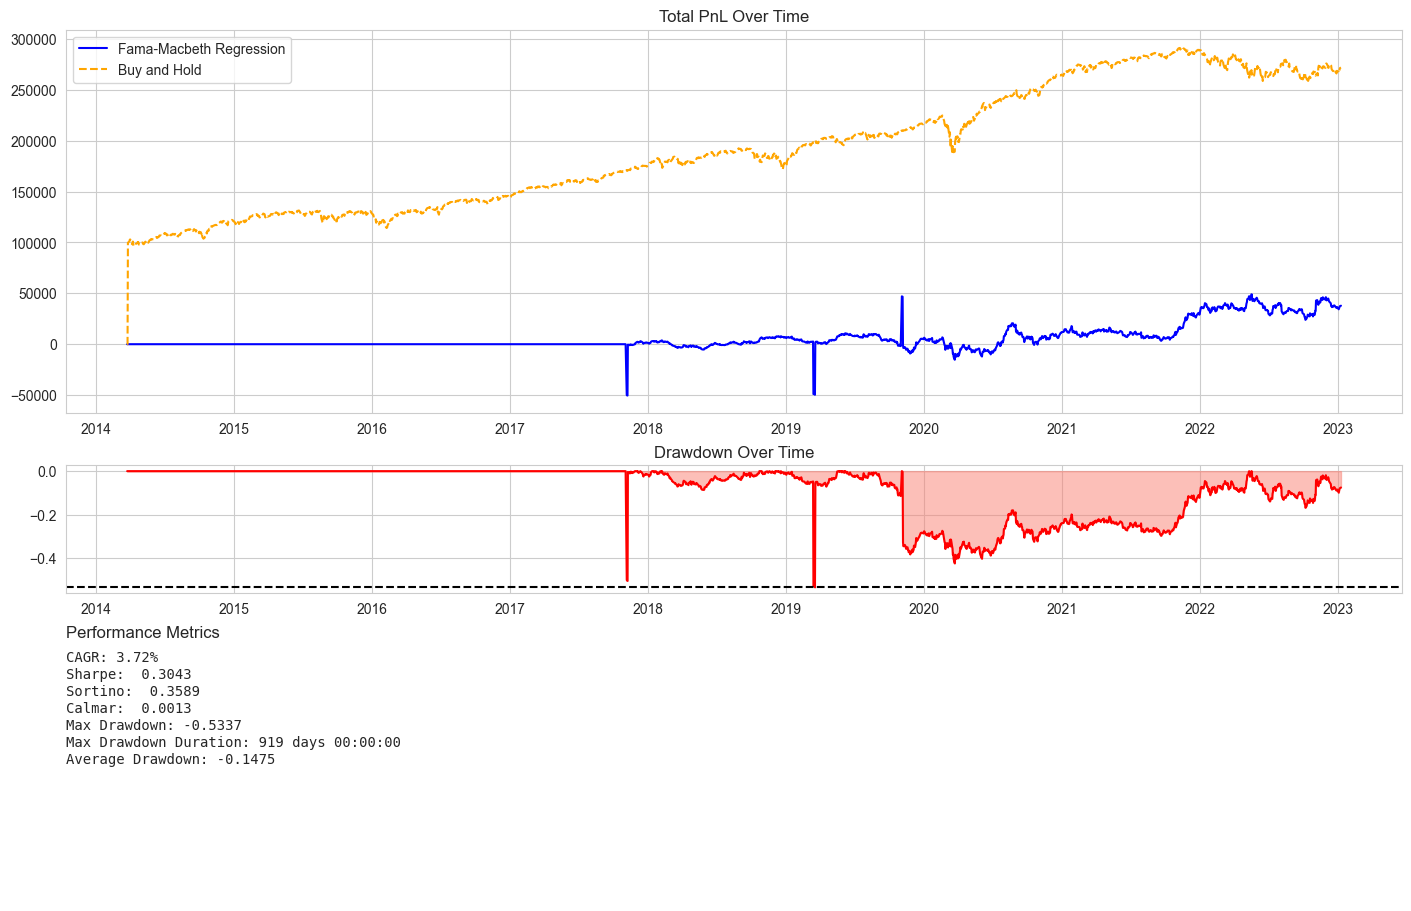

In [12]:
backtest_results.performance_dashboard()